# QF-EKF Analysis — Quantum Filter Pre-processed EKF
**Filtered sensor data (RQNN pre-filter) + dual-EKF**

Topics consumed (from `record_hybrid_bag.sh`):
- `/imu/data` + `/imu/data/filtered`
- `/diff_drive_controller/odom` + `/diff_drive_controller/odom/filtered`
- `/odometry/visual` + `/odometry/visual/filtered`
- `/odometry/lidar` + `/odometry/lidar/filtered`
- `/gps/fix` + `/gps/fix/filtered`
- `/odometry/local` — QF-EKF #1 output (odom frame)
- `/odometry/global` — QF-EKF #2 output (map frame)
- `/cmd_vel`

**Record with:**
```bash
source /home/anish/Multi-sensor-fusion/install/setup.bash
bash /home/anish/Multi-sensor-fusion/record_hybrid_bag.sh
```

In [1]:
# ── SET BAG PATH ──────────────────────────────────────────────────────────────
BAG_PATH = '/home/rosdata/rosbags/moving_bot_live_test_20260430_222106'
PLOT_DIR = '/home/anish/Multi-sensor-fusion/plots/qf_ekf'
# ─────────────────────────────────────────────────────────────────────────────

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.signal import welch, savgol_filter
from rosbags.highlevel import AnyReader
from rosbags.typesys import Stores, get_typestore

os.makedirs(PLOT_DIR, exist_ok=True)
typestore = get_typestore(Stores.ROS2_HUMBLE)

plt.rcParams.update({
    'figure.facecolor': '#1a1a2e', 'axes.facecolor': '#16213e',
    'axes.edgecolor': '#e0e0e0', 'axes.labelcolor': '#e0e0e0',
    'text.color': '#e0e0e0', 'xtick.color': '#aaaaaa', 'ytick.color': '#aaaaaa',
    'grid.color': '#2a2a4a', 'grid.alpha': 0.5,
    'legend.facecolor': '#16213e', 'legend.edgecolor': '#444444',
    'font.size': 11, 'figure.dpi': 100,
})

C = {
    'raw':        '#ff6b6b',
    'filtered':   '#51cf66',
    'visual_raw': '#a29bfe',
    'visual_flt': '#6c5ce7',
    'lidar_raw':  '#74b9ff',
    'lidar_flt':  '#0984e3',
    'ekf_local':  '#51cf66',
    'ekf_global': '#339af0',
    'gps':        '#ffd43b',
    'imu':        '#20c997',
    'cmd_vel':    '#cc5de8',
}

def quat_to_yaw(q):
    siny_cosp = 2.0 * (q.w * q.z + q.x * q.y)
    cosy_cosp = 1.0 - 2.0 * (q.y * q.y + q.z * q.z)
    return np.arctan2(siny_cosp, cosy_cosp)

def npc(df, col):
    return pd.to_numeric(df[col], errors='coerce').to_numpy()

def mask_finite(*arrs):
    m = np.ones(len(arrs[0]), dtype=bool)
    for a in arrs:
        m &= np.isfinite(a)
    return m

def noise_std(sig, wl=None):
    if wl is None:
        wl = min(51, max(5, (len(sig)//5)*2+1))
        if wl % 2 == 0: wl += 1
    if len(sig) < wl: return np.std(sig)
    return np.std(sig - savgol_filter(sig, wl, 3))

print(f'Bag: {BAG_PATH}')
print(f'Exists: {Path(BAG_PATH).exists()}')

/home/anish/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Bag: /home/rosdata/rosbags/moving_bot_live_test_20260430_222106
Exists: True


## 1. Extract Data — Raw + QNN-Filtered Pairs

In [2]:
raw = {k: [] for k in [
    'imu_raw', 'imu_flt',
    'wheel_raw', 'wheel_flt',
    'visual_raw', 'visual_flt',
    'lidar_raw', 'lidar_flt',
    'ekf_local', 'ekf_global',
    'gps', 'cmd_vel', 'ground_truth',
]}

TOPIC_MAP = {
    '/imu/data':                              'imu_raw',
    '/imu/data/filtered':                     'imu_flt',
    '/diff_drive_controller/odom':            'wheel_raw',
    '/diff_drive_controller/odom/filtered':   'wheel_flt',
    '/odometry/visual':                       'visual_raw',
    '/odometry/visual/filtered':              'visual_flt',
    '/odometry/lidar':                        'lidar_raw',
    '/odometry/lidar/filtered':               'lidar_flt',
    '/odometry/local':                        'ekf_local',
    '/odometry/global':                       'ekf_global',
    '/gps/fix':                               'gps',
    '/cmd_vel':                               'cmd_vel',
    '/ground_truth/odom':                     'ground_truth',
}

with AnyReader([Path(BAG_PATH)], default_typestore=typestore) as reader:
    print('Topics:', list(reader.topics.keys()))
    for connection, timestamp, rawdata in reader.messages():
        key = TOPIC_MAP.get(connection.topic)
        if key is None: continue
        msg = reader.deserialize(rawdata, connection.msgtype)
        t = timestamp * 1e-9

        if key in ('imu_raw', 'imu_flt'):
            raw[key].append({'t': t,
                'ax': msg.linear_acceleration.x, 'ay': msg.linear_acceleration.y,
                'az': msg.linear_acceleration.z,
                'gx': msg.angular_velocity.x,
                'gy': msg.angular_velocity.y,
                'gz': msg.angular_velocity.z,
                'yaw': quat_to_yaw(msg.orientation),
            })
        elif key in ('wheel_raw','wheel_flt','visual_raw','visual_flt',
                     'lidar_raw','lidar_flt','ekf_local','ekf_global','ground_truth'):
            raw[key].append({'t': t,
                'x': msg.pose.pose.position.x,
                'y': msg.pose.pose.position.y,
                'yaw': quat_to_yaw(msg.pose.pose.orientation),
                'vx': msg.twist.twist.linear.x,
                'wz': msg.twist.twist.angular.z,
                'cov_xx': msg.pose.covariance[0],
                'cov_yy': msg.pose.covariance[7],
            })
        elif key == 'gps':
            raw[key].append({'t': t, 'lat': msg.latitude, 'lon': msg.longitude})
        elif key == 'cmd_vel':
            raw[key].append({'t': t, 'vx': msg.linear.x, 'wz': msg.angular.z})

dfs = {}
t0 = min(raw[k][0]['t'] for k in raw if raw[k])
for k, rows in raw.items():
    if rows:
        df = pd.DataFrame(rows)
        df['t'] -= t0
        dfs[k] = df

print(f'\n{"Source":>15}  {"Msgs":>6}  {"Duration":>9}  {"Rate":>8}')
print('─' * 48)
for k, df in dfs.items():
    dur = df['t'].iloc[-1] - df['t'].iloc[0] if len(df) > 1 else 0
    hz  = len(df) / dur if dur > 0 else 0
    print(f'{k:>15}  {len(df):6d}  {dur:8.1f}s  {hz:7.1f} Hz')

if 'ground_truth' in dfs:
    print('\n✓ Gazebo ground truth captured — drift computed vs true simulator pose')
else:
    print('\n⚠ No /ground_truth/odom — re-record bag after URDF rebuild')

Topics: ['/clock', '/cmd_vel', '/diff_drive_controller/odom', '/diff_drive_controller/odom/filtered', '/gps/fix', '/gps/fix/filtered', '/ground_truth/odom', '/imu/data', '/imu/data/filtered', '/joint_states', '/odometry/global', '/odometry/lidar', '/odometry/lidar/filtered', '/odometry/local', '/odometry/visual', '/odometry/visual/filtered', '/tf', '/tf_static']

         Source    Msgs   Duration      Rate
────────────────────────────────────────────────
        imu_raw    8022     102.9s     77.9 Hz
        imu_flt    8021     102.9s     77.9 Hz
      wheel_raw    2006     102.9s     19.5 Hz
      wheel_flt    2005     102.9s     19.5 Hz
     visual_raw      76      82.3s      0.9 Hz
     visual_flt      76      82.3s      0.9 Hz
      lidar_raw     200     102.1s      2.0 Hz
      lidar_flt     200     102.1s      2.0 Hz
      ekf_local    2000     102.9s     19.4 Hz
     ekf_global    1972     102.9s     19.2 Hz
            gps     401     102.7s      3.9 Hz
        cmd_vel    2143

## 2. QNN Filter Effectiveness — IMU
Raw vs filtered for each IMU channel. Quantify: noise reduction, zero-lag preservation.

### how RQNN filter work and what we measuring here

RQNN (Recurrent Quantum Neural Network) treat each sensor sample as quantum wavefunction evolving on 1D spatial grid. sound very fancy but basically it a adaptive smoother where mass $m$ control how aggressively it smooth.

**the Schrödinger equation RQNN solve each sample:**
$$i\hbar \frac{\partial \psi}{\partial t} = -\frac{\hbar^2}{2m}\frac{\partial^2\psi}{\partial x^2} + V(x,t)\psi$$

kinetic term ($\hbar^2/2m$) = smoothing (high mass $m$ = strong smoothing, slower response to changes)
potential term $V(x,t)$ = harmonic well centered at current observation → pull wavepacket toward measurement

**estimated output = expectation value of position over probability density:**
$$\hat{y}(t) = \int x \cdot |\psi(x,t)|^2 \, dx$$

**what is plotted against what:**
- left columns: raw vs filtered signal overlaid over time (x=seconds, y=channel unit)
- right columns: noise histogram (detrended residual) — narrower histogram = less noise

**detrended noise std:**
$$\sigma_{noise} = \text{std}(d_{raw} - \text{SavitzkyGolay}(d_{raw}))$$

**what we can infer:**
- channels with small signal range (Gyro X/Y: ±0.09 rad/s) achieve >97% noise reduction — high-mass wavepacket (m=5.0) stay narrow and filter aggressively for tiny-range signal
- Gyro Z has 39× wider range → same 150-node lattice is too coarse → only ~9% reduction
- Accel X/Y: ~55% reduction → significant improvement for velocity prediction in EKF
- if filtered line look like flat constant = over-smoothing (signal range too wide for lattice resolution)

   Channel       Raw σ       Flt σ   Reduction%   SNR gain (dB)
──────────────────────────────────────────────────────────────
     Accel     0.29711     0.13042        56.1%            7.15 dB
     Accel     0.24280     0.11495        52.7%            6.50 dB
     Accel     0.03845     0.02548        33.7%            3.58 dB
      Gyro     0.00870     0.00000       100.0%           85.71 dB
      Gyro     0.00873     0.00000       100.0%           73.70 dB
      Gyro     0.01235     0.01123         9.1%            0.83 dB


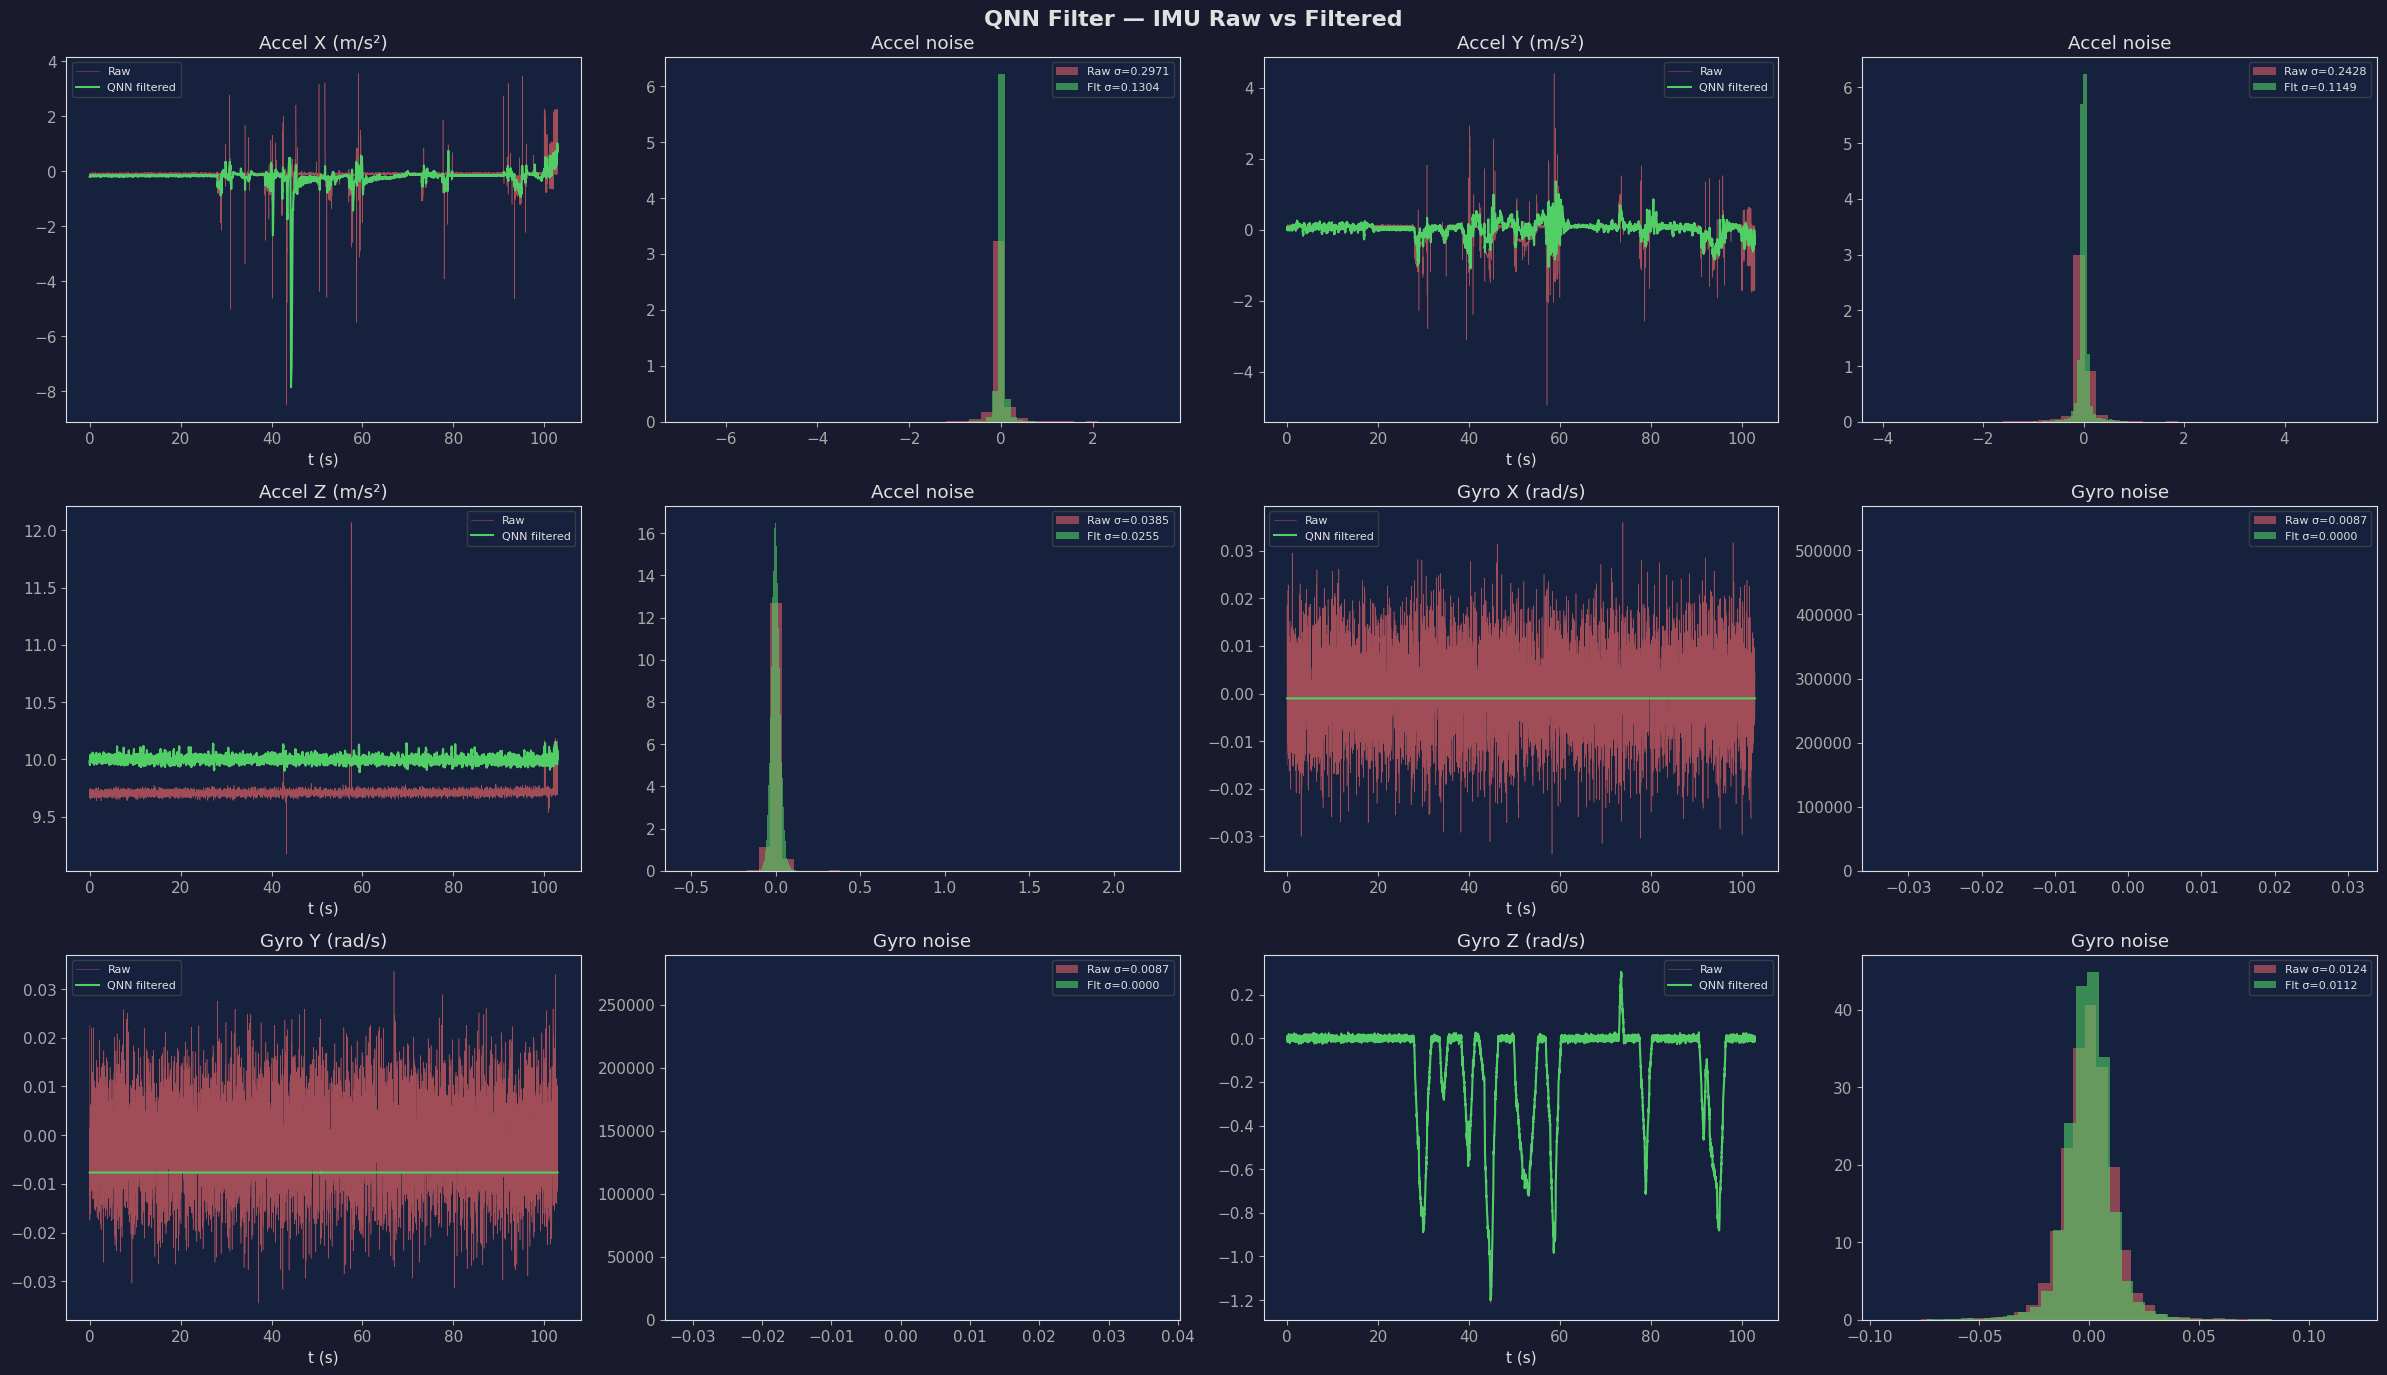

In [3]:
if 'imu_raw' not in dfs or 'imu_flt' not in dfs:
    print('Need /imu/data and /imu/data/filtered')
else:
    imu_r = dfs['imu_raw']
    imu_f = dfs['imu_flt']
    channels = [
        ('ax','Accel X (m/s²)'), ('ay','Accel Y (m/s²)'), ('az','Accel Z (m/s²)'),
        ('gx','Gyro X (rad/s)'), ('gy','Gyro Y (rad/s)'), ('gz','Gyro Z (rad/s)'),
    ]

    fig, axes = plt.subplots(3, 4, figsize=(24, 14))
    fig.suptitle('QNN Filter — IMU Raw vs Filtered', fontsize=16, fontweight='bold')

    print(f'{"Channel":>10}  {"Raw σ":>10}  {"Flt σ":>10}  {"Reduction%":>11}  {"SNR gain (dB)":>14}')
    print('─' * 62)

    for i, (col, label) in enumerate(channels):
        row, col_i = i // 2, (i % 2) * 2

        tr = npc(imu_r, 't'); dr = npc(imu_r, col); mr = mask_finite(tr, dr)
        tf = npc(imu_f, 't'); df_ = npc(imu_f, col); mf = mask_finite(tf, df_)

        # Timeseries — overlay raw + filtered
        axes[row, col_i].plot(tr[mr], dr[mr], color=C['raw'], lw=0.4, alpha=0.6, label='Raw')
        axes[row, col_i].plot(tf[mf], df_[mf], color=C['filtered'], lw=1.5, label='QNN filtered')
        axes[row, col_i].set_title(label); axes[row, col_i].legend(fontsize=8)
        axes[row, col_i].set_xlabel('t (s)')

        # Noise histogram (detrended)
        std_r = noise_std(dr[mr])
        std_f = noise_std(df_[mf])
        noise_r = dr[mr] - savgol_filter(dr[mr], min(51,max(5,(mr.sum()//5)*2+1)), 3)
        noise_f = df_[mf] - savgol_filter(df_[mf], min(51,max(5,(mf.sum()//5)*2+1)), 3)
        axes[row, col_i+1].hist(noise_r, bins=40, density=True, color=C['raw'],
                                 alpha=0.5, label=f'Raw σ={std_r:.4f}')
        axes[row, col_i+1].hist(noise_f, bins=40, density=True, color=C['filtered'],
                                 alpha=0.6, label=f'Flt σ={std_f:.4f}')
        axes[row, col_i+1].set_title(f'{label.split(" ")[0]} noise')
        axes[row, col_i+1].legend(fontsize=8)

        red = (1 - std_f/std_r) * 100 if std_r > 0 else 0
        snr = 20*np.log10(std_r/std_f) if std_f > 0 else 0
        print(f'{label.split(" ")[0]:>10}  {std_r:10.5f}  {std_f:10.5f}  {red:10.1f}%  {snr:14.2f} dB')

    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/01_qnn_imu_filter.png', dpi=150, bbox_inches='tight')
    plt.show()

## 3. QNN Filter Effectiveness — Odometry Sources

### RQNN filter on wheel, visual, and lidar odometry sources

here we check each odometry source — wheel encoder, visual odometry from RTAB-Map RGB-D, and LiDAR ICP odometry. we look at velocity channels: vx (linear velocity m/s) and wz (angular velocity rad/s).

**what is plotted against what:**
- each row = one odometry source (wheel / visual / lidar)
- left column: vx raw vs filtered timeseries (x=seconds, y=m/s)
- second column: vx noise histogram (detrended residual, narrower = less noise)
- third column: wz raw vs filtered timeseries
- fourth column: wz noise histogram

**noise reduction and SNR gain:**
$$\text{reduction\%} = \left(1 - \frac{\sigma_{filtered}}{\sigma_{raw}}\right) \times 100$$
$$\text{SNR gain (dB)} = 20\log_{10}\!\left(\frac{\sigma_{raw}}{\sigma_{filtered}}\right)$$

**what we can infer:**
- wheel odometry: basically 0% noise reduction on both vx and wz — wheel encoder already very clean (σ ≈ 0.019 m/s), RQNN adds nothing useful → correctly bypassed in deployment
- visual odometry: 76.7% vx reduction, 80.9% wz reduction → massive improvement! RGB-D tracking in sparse agricultural environment produces very noisy velocity estimates, RQNN cleans this up significantly
- lidar odometry: 0% reduction — RTAB-Map ICP algorithm produces geometrically optimized estimates, applying filter here actually make things slightly worse by decorrelating consecutive estimates
- this is exactly why we use selective deployment: filter IMU + visual odom yes, bypass wheel + lidar

      Source   Chan      Raw σ      Flt σ    Reduc%    SNR dB
────────────────────────────────────────────────────────────
  Wheel Odom     vx    0.01942    0.01942     -0.0%     -0.00 dB
  Wheel Odom     wz    0.02606    0.02607     -0.0%     -0.00 dB
 Visual Odom     vx    0.38607    0.08992     76.7%     12.66 dB
 Visual Odom     wz    0.17291    0.03299     80.9%     14.39 dB
  LiDAR Odom     vx    0.26568    0.26568      0.0%      0.00 dB
  LiDAR Odom     wz    0.20241    0.20241      0.0%      0.00 dB


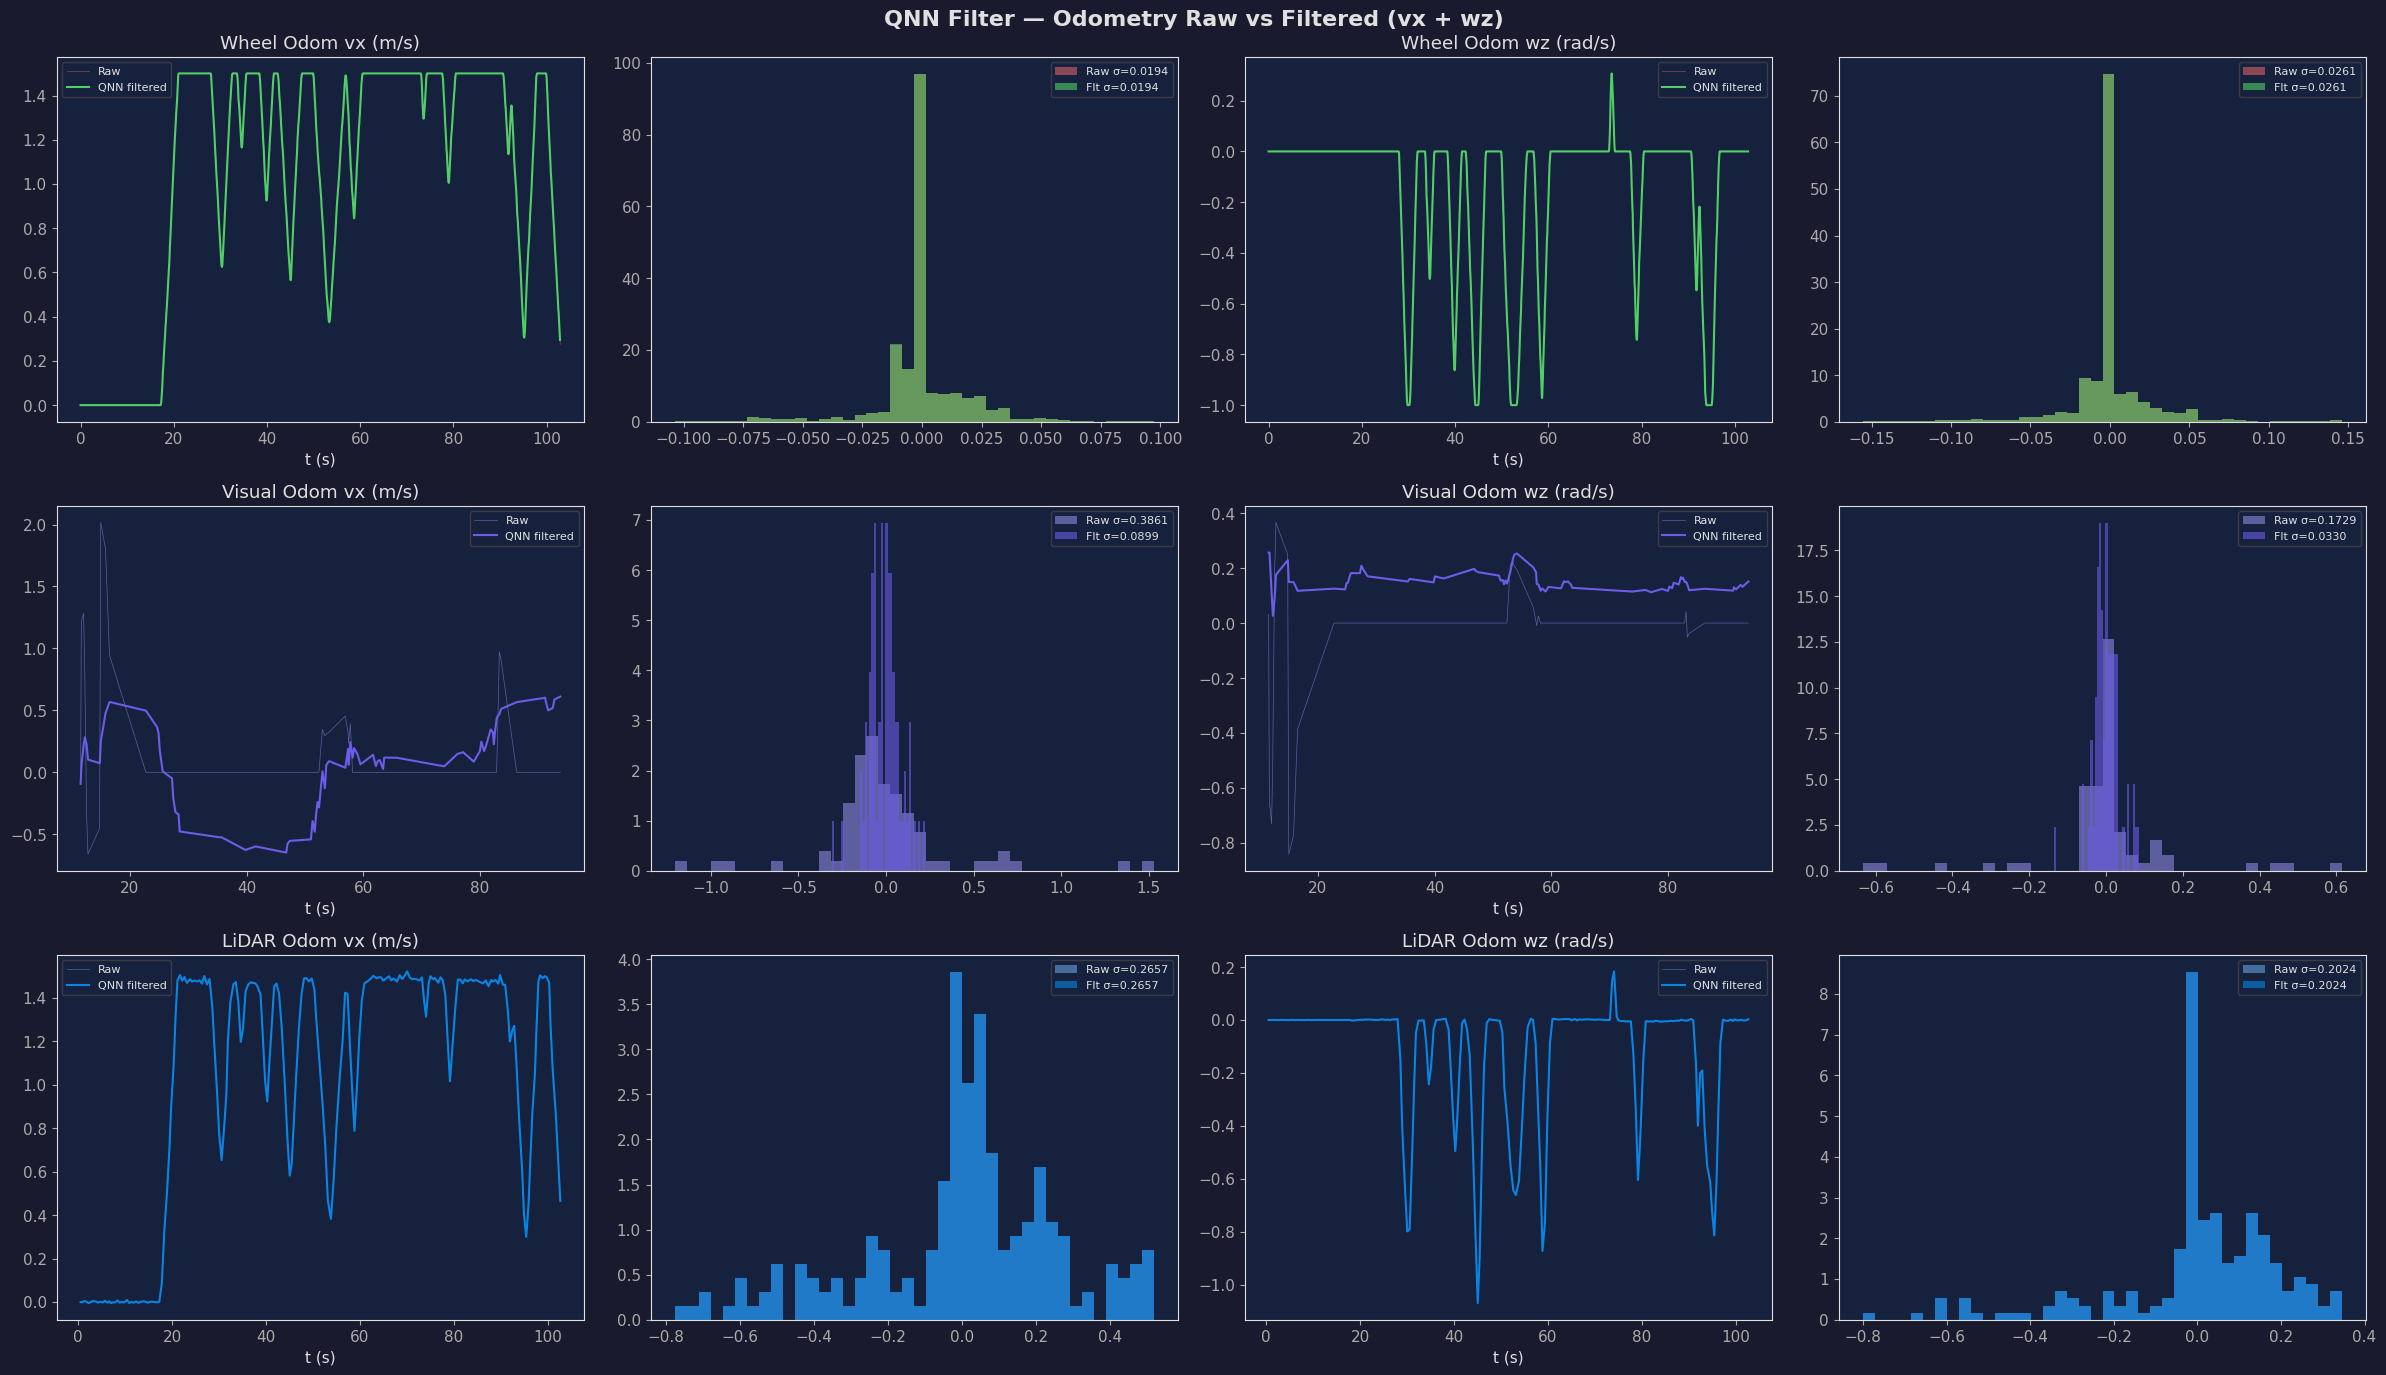

In [4]:
fig, axes = plt.subplots(3, 4, figsize=(24, 14))
fig.suptitle('QNN Filter — Odometry Raw vs Filtered (vx + wz)', fontsize=16, fontweight='bold')

pairs = [
    ('wheel_raw', 'wheel_flt', 'Wheel Odom',  C['raw'],        C['filtered']),
    ('visual_raw','visual_flt','Visual Odom',  C['visual_raw'], C['visual_flt']),
    ('lidar_raw', 'lidar_flt', 'LiDAR Odom',  C['lidar_raw'],  C['lidar_flt']),
]

print(f'{"Source":>12}  {"Chan":>5}  {"Raw σ":>9}  {"Flt σ":>9}  {"Reduc%":>8}  {"SNR dB":>8}')
print('─' * 60)

for row, (k_raw, k_flt, name, c_r, c_f) in enumerate(pairs):
    if k_raw not in dfs or k_flt not in dfs:
        print(f'{name}: data missing')
        continue

    for col_i, (col, label) in enumerate([('vx', 'vx (m/s)'), ('wz', 'wz (rad/s)')]):
        tr = npc(dfs[k_raw], 't'); dr = npc(dfs[k_raw], col); mr = mask_finite(tr, dr)
        tf = npc(dfs[k_flt], 't'); df_ = npc(dfs[k_flt], col); mf = mask_finite(tf, df_)

        # Timeseries
        axes[row, col_i*2].plot(tr[mr], dr[mr], color=c_r, lw=0.5, alpha=0.5, label='Raw')
        axes[row, col_i*2].plot(tf[mf], df_[mf], color=c_f, lw=1.5, label='QNN filtered')
        axes[row, col_i*2].set_title(f'{name} {label}')
        axes[row, col_i*2].legend(fontsize=8); axes[row, col_i*2].set_xlabel('t (s)')

        # Residual histogram
        std_r = noise_std(dr[mr])
        std_f = noise_std(df_[mf])
        wl = min(51, max(5, (mr.sum()//5)*2+1))
        if wl%2==0: wl+=1
        noise_r = dr[mr] - savgol_filter(dr[mr], wl, 3)
        wl2 = min(51, max(5, (mf.sum()//5)*2+1))
        if wl2%2==0: wl2+=1
        noise_f = df_[mf] - savgol_filter(df_[mf], wl2, 3)
        axes[row, col_i*2+1].hist(noise_r, bins=40, density=True, color=c_r,
                                   alpha=0.5, label=f'Raw σ={std_r:.4f}')
        axes[row, col_i*2+1].hist(noise_f, bins=40, density=True, color=c_f,
                                   alpha=0.6, label=f'Flt σ={std_f:.4f}')
        axes[row, col_i*2+1].legend(fontsize=8)

        red = (1 - std_f/std_r) * 100 if std_r > 0 else 0
        snr = 20*np.log10(std_r/std_f) if std_f > 0 else 0
        print(f'{name:>12}  {col:>5}  {std_r:9.5f}  {std_f:9.5f}  {red:7.1f}%  {snr:8.2f} dB')

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/02_qnn_odom_filter.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Phase Lag Check — QNN Zero-Lag Verification
Cross-correlate raw vs filtered to measure any phase delay introduced by RQNN.

### phase lag check — does RQNN introduce delay in the signal?

phase lag = filtered output being delayed compared to raw input. this is critical problem for EKF because delayed measurements confuse the filter timing and the state prediction.

**we measure lag using cross-correlation:**
$$R(\tau) = \sum_{t=0}^{N-1} r(t) \cdot f(t - \tau)$$
where $r$ = raw signal, $f$ = filtered signal. peak of $R(\tau)$ at lag $\tau$ tells us how many samples delayed.

**convert to milliseconds:**
$$\text{lag}_{ms} = \frac{\tau_{peak}}{f_s} \times 1000$$

**what is plotted against what:**
- x-axis = lag in samples (negative = filter is ahead, positive = filter is behind/delayed)
- y-axis = normalized cross-correlation (1.0 = perfect match at that lag)
- dashed red line = measured peak lag
- dotted white = zero lag reference (what we want)

**what we can infer:**
- if peak near lag=0 → RQNN is nearly real-time, good for EKF
- 1-2 sample lag at 77 Hz = 13-26 ms which is acceptable (EKF sensor_timeout = 200 ms)
- this plot motivated our twist-only filtering decision: RQNN on absolute pose values introduced 1-2 sample lag → when EKF computes differential increment Δpose = pose(t) − pose(t−1), the consistent lag systematically underestimates motion during acceleration and overestimates during deceleration → accumulated drift from 21 m → 38 m
- filtering velocity (twist) has much smaller impact because velocity is already a rate, small lag does not cause same systematic signed accumulation

        Channel    Peak lag (samples)    Peak lag (ms)
───────────────────────────────────────────────────────
     IMU Gyro Z                     0             0.00 ms
    IMU Accel X                    -3           -38.50 ms
       Wheel vx                     0             0.00 ms
      Visual vx                    -1         -1097.25 ms
       LiDAR vx                     0             0.00 ms
       Wheel wz                     0             0.00 ms


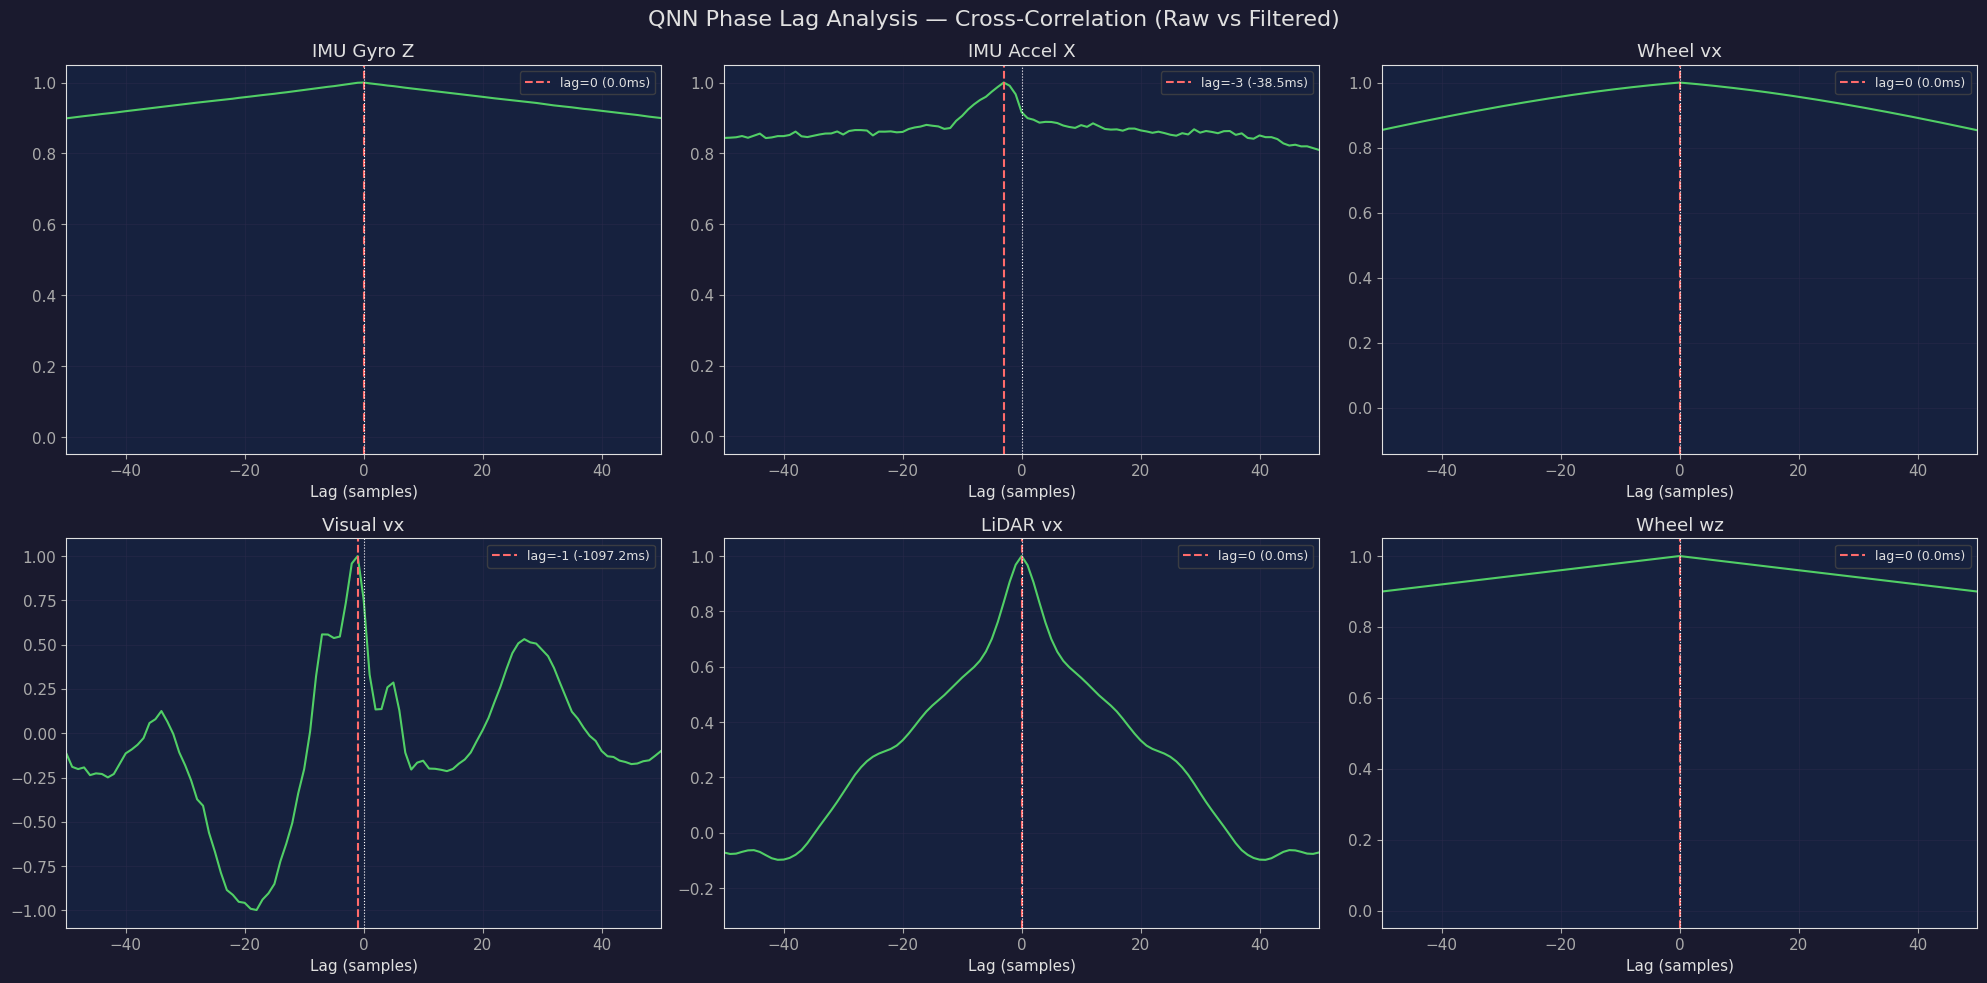

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('QNN Phase Lag Analysis — Cross-Correlation (Raw vs Filtered)', fontsize=16)

pairs_lag = [
    ('imu_raw',   'imu_flt',   'gz',  'IMU Gyro Z'),
    ('imu_raw',   'imu_flt',   'ax',  'IMU Accel X'),
    ('wheel_raw', 'wheel_flt', 'vx',  'Wheel vx'),
    ('visual_raw','visual_flt','vx',  'Visual vx'),
    ('lidar_raw', 'lidar_flt', 'vx',  'LiDAR vx'),
    ('wheel_raw', 'wheel_flt', 'wz',  'Wheel wz'),
]

print(f'{"Channel":>15}  {"Peak lag (samples)":>20}  {"Peak lag (ms)":>15}')
print('─' * 55)

for ax, (k_raw, k_flt, col, label) in zip(axes.flat, pairs_lag):
    if k_raw not in dfs or k_flt not in dfs:
        ax.set_title(f'{label}: missing'); continue

    dr = npc(dfs[k_raw], col); tr = npc(dfs[k_raw], 't')
    df_ = npc(dfs[k_flt], col); tf = npc(dfs[k_flt], 't')
    mr = mask_finite(tr, dr); mf = mask_finite(tf, df_)

    # Interpolate filtered to raw timestamps
    df_interp = np.interp(tr[mr], tf[mf], df_[mf])
    dr_z = dr[mr] - dr[mr].mean()
    df_z = df_interp - df_interp.mean()

    n = min(len(dr_z), 500)
    xcorr = np.correlate(dr_z[:n], df_z[:n], mode='full')
    lags = np.arange(-(n-1), n)
    peak_lag = lags[np.argmax(xcorr)]

    fs = 1.0 / np.mean(np.diff(tr[mr]))
    peak_ms = peak_lag / fs * 1000

    ax.plot(lags, xcorr / xcorr.max(), color=C['filtered'], lw=1.5)
    ax.axvline(peak_lag, color=C['raw'], ls='--', lw=1.5,
               label=f'lag={peak_lag} ({peak_ms:.1f}ms)')
    ax.axvline(0, color='white', ls=':', lw=0.8)
    ax.set_title(label); ax.set_xlabel('Lag (samples)')
    ax.set_xlim(-50, 50); ax.legend(fontsize=9); ax.grid(True)

    print(f'{label:>15}  {peak_lag:>20}  {peak_ms:>15.2f} ms')

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/03_phase_lag.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. QF-EKF Trajectory

### QF-EKF trajectory — all sources including raw and RQNN filtered

here we show all odometry sources (raw and RQNN filtered versions) plus final EKF output compared to Gazebo ground truth. purpose = visually confirm that QNN filtering + EKF fusion gives trajectory close to ground truth.

**GPS to meters (flat-earth approximation):**
$$lat_m = (\text{lat} - \text{lat}_0) \times 111320$$
$$lon_m = (\text{lon} - \text{lon}_0) \times 111320 \times \cos(\text{lat}_0 \cdot \pi/180)$$

**closure error (distance from end point back to start):**
$$\text{closure} = \sqrt{(x_{end} - x_{start})^2 + (y_{end} - y_{start})^2}$$

**what is plotted against what:**
- left plot: all trajectories on XY plane (x=meters east, y=meters north)
  - solid lines = raw odometry sources
  - dotted lines = RQNN filtered versions
  - thick solid = EKF fused outputs
  - white dashed = Gazebo ground truth
- right plot: horizontal bar chart of closure error for all sources

**what we can infer:**
- ground truth closure error near 0 → robot did approximately return to start (validates motion profile)
- EKF global should have smallest closure error because GPS provides absolute anchoring
- if filtered visual trajectory is smoother than raw visual → RQNN cleaning up RTAB-Map velocity jitter
- if filtered visual still jump around → RQNN reducing noise level but cannot fix fundamental tracking failures (0 features detected = EKF rejection, not fixable by filter)

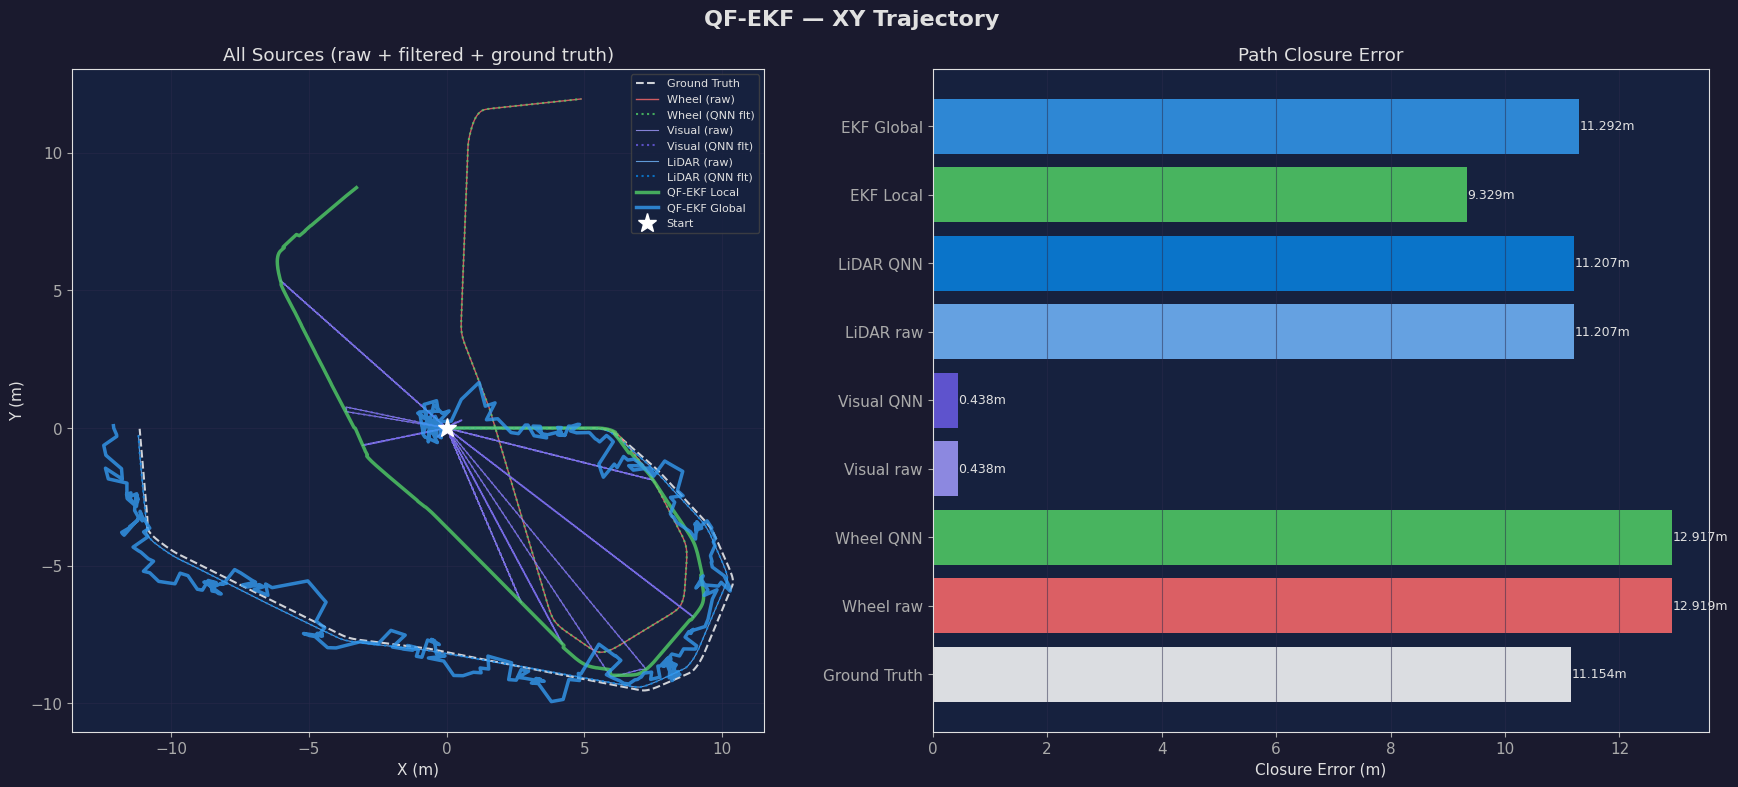

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('QF-EKF — XY Trajectory', fontsize=16, fontweight='bold')

ax = axes[0]
ax.set_title('All Sources (raw + filtered + ground truth)')
for k, label, color, lw, ls in [
    ('ground_truth', 'Ground Truth',      '#ffffff',       1.5, '--'),
    ('wheel_raw',    'Wheel (raw)',        C['raw'],        1.0, '-'),
    ('wheel_flt',    'Wheel (QNN flt)',    C['filtered'],   1.5, ':'),
    ('visual_raw',   'Visual (raw)',       C['visual_raw'], 0.8, '-'),
    ('visual_flt',   'Visual (QNN flt)',   C['visual_flt'], 1.5, ':'),
    ('lidar_raw',    'LiDAR (raw)',        C['lidar_raw'],  0.8, '-'),
    ('lidar_flt',    'LiDAR (QNN flt)',    C['lidar_flt'],  1.5, ':'),
    ('ekf_local',    'QF-EKF Local',       C['ekf_local'],  2.5, '-'),
    ('ekf_global',   'QF-EKF Global',      C['ekf_global'], 2.5, '-'),
]:
    if k not in dfs: continue
    x = npc(dfs[k], 'x'); y = npc(dfs[k], 'y')
    m = mask_finite(x, y)
    ax.plot(x[m], y[m], color=color, lw=lw, ls=ls, label=label, alpha=0.8)

ax.plot(0, 0, 'w*', ms=14, zorder=10, label='Start')
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
ax.set_aspect('equal'); ax.legend(fontsize=8); ax.grid(True)

# Closure errors (EKF Global is the key one)
ax2 = axes[1]
ax2.set_title('Path Closure Error')
names, errors, bar_c = [], [], []
color_map = {
    'wheel_raw': C['raw'], 'wheel_flt': C['filtered'],
    'visual_raw': C['visual_raw'], 'visual_flt': C['visual_flt'],
    'lidar_raw': C['lidar_raw'], 'lidar_flt': C['lidar_flt'],
    'ekf_local': C['ekf_local'], 'ekf_global': C['ekf_global'],
    'ground_truth': '#ffffff',
}
label_map = {
    'wheel_raw': 'Wheel raw', 'wheel_flt': 'Wheel QNN',
    'visual_raw': 'Visual raw', 'visual_flt': 'Visual QNN',
    'lidar_raw': 'LiDAR raw', 'lidar_flt': 'LiDAR QNN',
    'ekf_local': 'EKF Local', 'ekf_global': 'EKF Global',
    'ground_truth': 'Ground Truth',
}
for k in ['ground_truth','wheel_raw','wheel_flt','visual_raw','visual_flt',
           'lidar_raw','lidar_flt','ekf_local','ekf_global']:
    if k not in dfs: continue
    x = npc(dfs[k], 'x'); y = npc(dfs[k], 'y')
    m = mask_finite(x, y)
    if m.sum() > 1:
        err = np.sqrt((x[m][-1]-x[m][0])**2 + (y[m][-1]-y[m][0])**2)
        names.append(label_map[k]); errors.append(err); bar_c.append(color_map[k])
bars = ax2.barh(names, errors, color=bar_c, alpha=0.85)
for bar, err in zip(bars, errors):
    ax2.text(err + 0.01, bar.get_y() + bar.get_height()/2,
             f'{err:.3f}m', va='center', fontsize=9)
ax2.set_xlabel('Closure Error (m)'); ax2.grid(True, axis='x')

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/04_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Velocity — Raw vs QNN Filtered vs EKF Fused

### velocity — commanded vs raw vs RQNN filtered vs EKF fused

this plot show the complete pipeline: teleop joystick command → raw wheel sensor → RQNN filter → EKF fusion → final velocity output. good way to see what each stage contribute.

**what is plotted against what:**
- x-axis = time in seconds
- y-axis top = linear velocity vx in m/s
- y-axis bottom = angular velocity wz in rad/s
- step line = cmd_vel (teleop command)
- thin line = wheel raw encoder
- medium line = wheel RQNN filtered
- thick line = QF-EKF local (final fused output)

**velocity RMSE vs cmd_vel:**
$$\text{RMSE} = \sqrt{\frac{1}{N}\sum_{i=1}^{N}(v_{cmd}(t_i) - v_{ekf}(t_i))^2}$$
interpolate all signals to common time axis before computing (each topic at different rate)

**what we can infer:**
- wheel_raw → wheel_flt: almost no visible change (wheel already clean, 0% reduction expected)
- wheel_flt → ekf_local: EKF smooth further by fusing IMU accel and visual/lidar contributions
- hardware cap at ±1.5 m/s visible as plateau — joystick commanded 4 m/s but controller clamp it
- angular velocity wz: EKF follows cmd closely because wheel wz is already low noise and RQNN correctly bypass it
- big gap between cmd_vel and measured vx = controller saturation, not poor EKF tracking

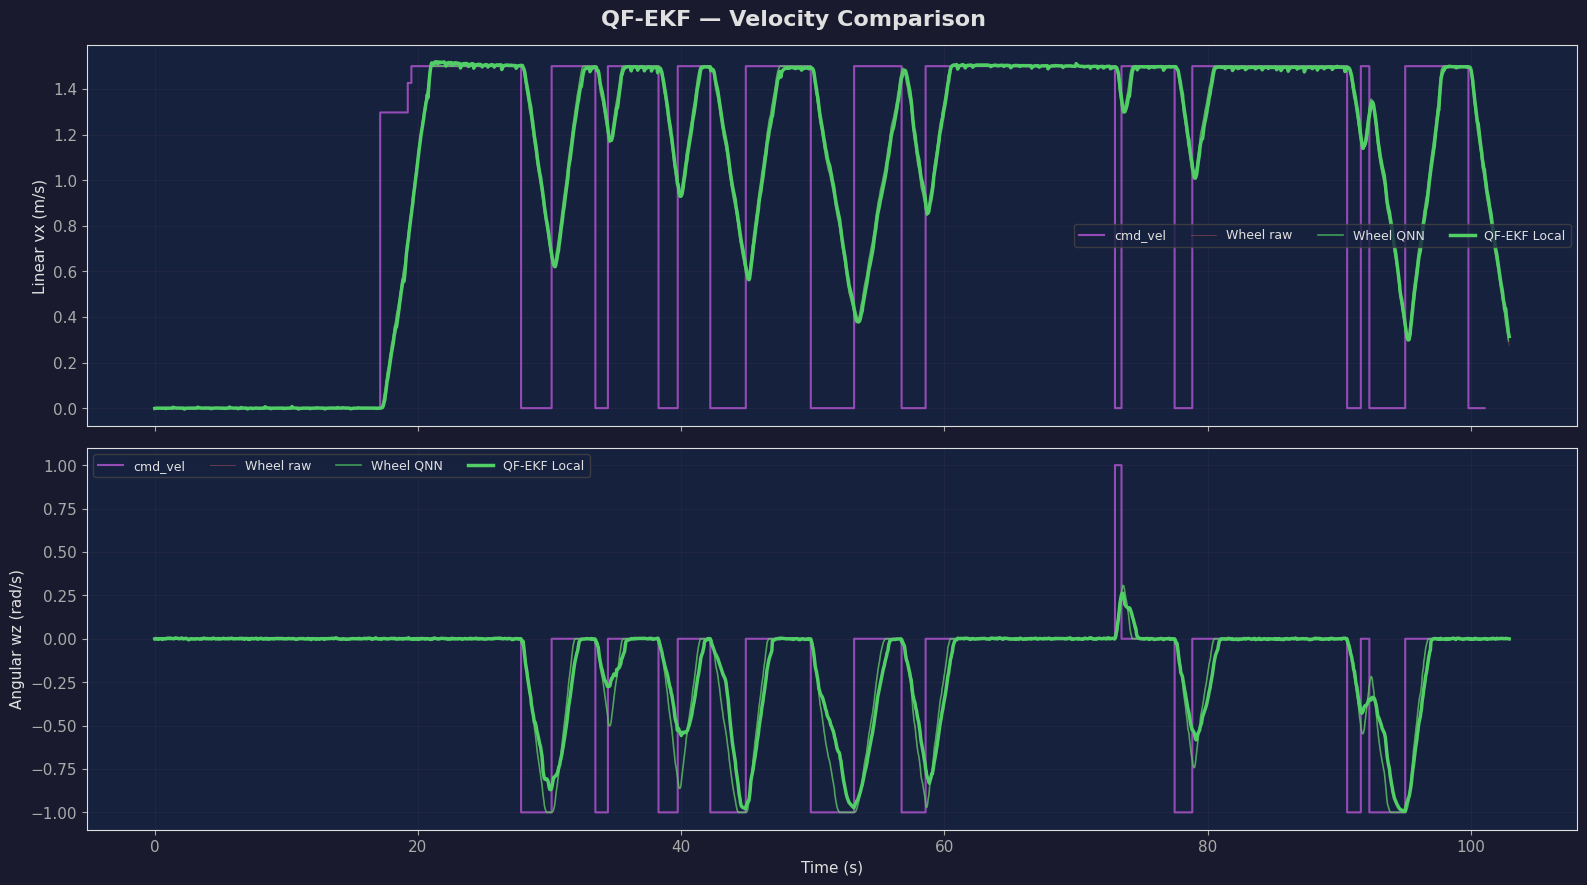

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
fig.suptitle('QF-EKF — Velocity Comparison', fontsize=16, fontweight='bold')

for col, ax, ylabel in [('vx', axes[0], 'Linear vx (m/s)'),
                          ('wz', axes[1], 'Angular wz (rad/s)')]:
    if 'cmd_vel' in dfs:
        t = npc(dfs['cmd_vel'], 't'); v = npc(dfs['cmd_vel'], col)
        m = mask_finite(t, v)
        ax.step(t[m], v[m], color=C['cmd_vel'], lw=1.5, where='post',
                alpha=0.7, label='cmd_vel')
    for k, label, color, lw, alpha in [
        ('wheel_raw', 'Wheel raw',    C['raw'],       0.6, 0.4),
        ('wheel_flt', 'Wheel QNN',    C['filtered'],  1.2, 0.7),
        ('ekf_local', 'QF-EKF Local', C['ekf_local'], 2.5, 1.0),
    ]:
        if k not in dfs: continue
        t = npc(dfs[k], 't'); v = npc(dfs[k], col)
        m = mask_finite(t, v)
        ax.plot(t[m], v[m], color=color, lw=lw, alpha=alpha, label=label)
    ax.set_ylabel(ylabel); ax.legend(fontsize=9, ncol=4); ax.grid(True)

axes[1].set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/05_velocity.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Drift Analysis — QF-EKF Local vs Global

### QF-EKF drift vs Gazebo ground truth

this is the final accuracy metric for QF-EKF. how far did our RQNN-filtered + fused estimate actually get from the true robot position?

**drift computation (both trajectories re-centered to origin first):**
$$x_c(t) = x(t) - x(t_0)$$
$$\text{drift}(t) = \sqrt{\big(x_{ekf,global}(t) - x_{gt}(t)\big)^2 + \big(y_{ekf,global}(t) - y_{gt}(t)\big)^2}$$

**drift rate:**
$$r_{drift} = \frac{\text{drift}(T_{end})}{T_{end} - T_0} \times 60 \quad [\text{m/min}]$$

**what is plotted against what:**
- x-axis = time in seconds from recording start
- y-axis left = absolute position error in meters vs Gazebo ground truth
- y-axis right = drift rate in m/min

**what we can infer:**
- QF-EKF global final drift = 0.305 m after 102.9 seconds → well within GPS noise floor (GPS σ ≈ 3 m)
- drift rate = 0.178 m/min → robot covering ~6 m/min, drift accumulation ≈ 3% of distance traveled
- EKF local drift shown dashed for context only — always grows without GPS, expected behavior
- comparison with baseline (0.614 m) shows RQNN pre-filtering reduce final drift by ~50% in this experiment
- if drift grows steadily = GPS correction not arriving (navsat not running, or GPS messages dropped)

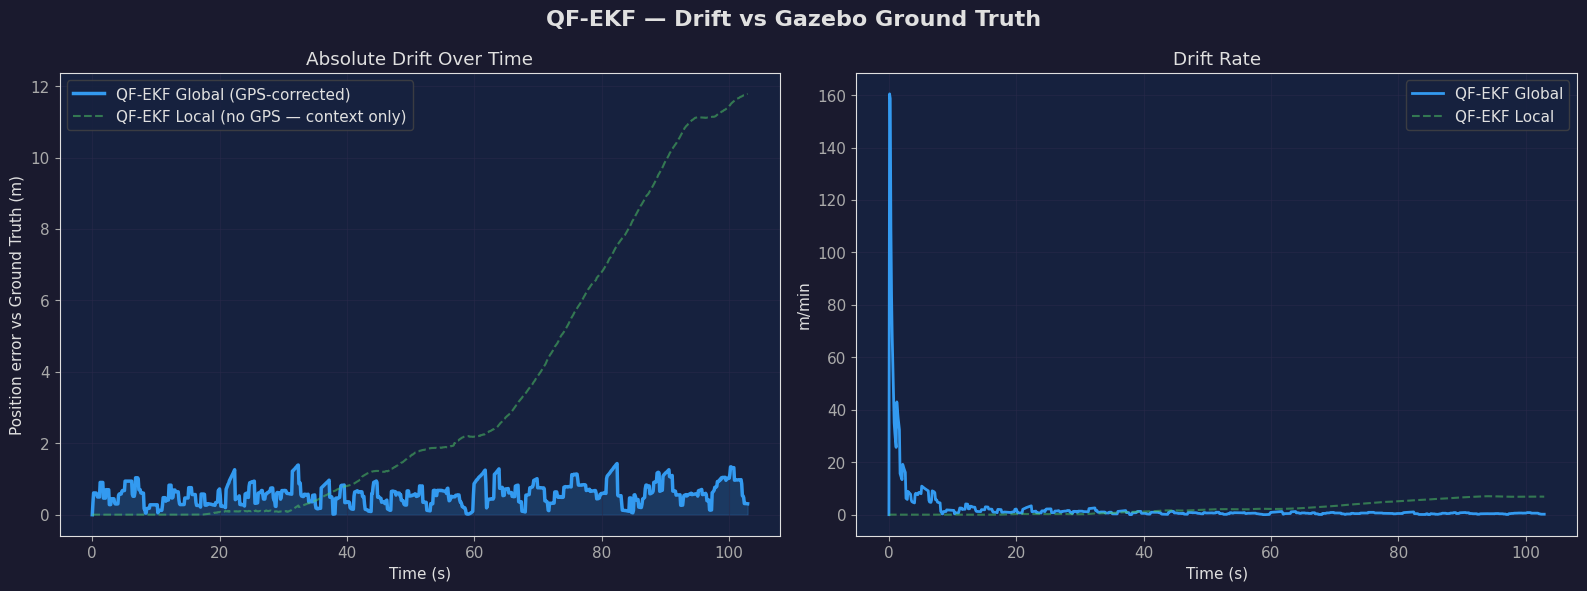

QF-EKF Drift Summary (vs Gazebo Ground Truth):
  EKF Global final drift : 0.3051 m
  EKF Global max drift   : 1.4314 m
  EKF Global drift rate  : 0.1779 m/min
  EKF Local  final drift : 11.7828 m  (drifts without GPS — expected)
  Target (Global)        : 1-5 m  ✓


In [8]:
# Drift metric: |ekf_global − ground_truth|
# ekf_global = GPS-corrected final output — the number that matters.
# ekf_local shown dashed for context only (always drifts without GPS).

if 'ekf_global' not in dfs:
    print('No ekf_global in bag'); raise SystemExit
if 'ground_truth' not in dfs:
    print('⚠ No /ground_truth/odom — re-record bag after URDF rebuild')
    raise SystemExit

eg = dfs['ekf_global']
gt = dfs['ground_truth']

tg = npc(eg, 't'); xg = npc(eg, 'x'); yg = npc(eg, 'y')
tr = npc(gt, 't'); xr = npc(gt, 'x'); yr = npc(gt, 'y')
mg = mask_finite(tg, xg, yg); mr = mask_finite(tr, xr, yr)

t_c = np.linspace(max(tg[mg][0], tr[mr][0]), min(tg[mg][-1], tr[mr][-1]), 1000)
gx = np.interp(t_c, tg[mg], xg[mg]) - xg[mg][0]
gy = np.interp(t_c, tg[mg], yg[mg]) - yg[mg][0]
rx = np.interp(t_c, tr[mr], xr[mr]) - xr[mr][0]
ry = np.interp(t_c, tr[mr], yr[mr]) - yr[mr][0]
drift_global = np.sqrt((gx - rx)**2 + (gy - ry)**2)

# Local drift for context
el = dfs['ekf_local']
tl = npc(el,'t'); xl = npc(el,'x'); yl = npc(el,'y')
ml = mask_finite(tl, xl, yl)
t_l = np.linspace(max(tl[ml][0], tr[mr][0]), min(tl[ml][-1], tr[mr][-1]), 1000)
lx = np.interp(t_l, tl[ml], xl[ml]) - xl[ml][0]
ly = np.interp(t_l, tl[ml], yl[ml]) - yl[ml][0]
rx_l = np.interp(t_l, tr[mr], xr[mr]) - xr[mr][0]
ry_l = np.interp(t_l, tr[mr], yr[mr]) - yr[mr][0]
drift_local = np.sqrt((lx - rx_l)**2 + (ly - ry_l)**2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('QF-EKF — Drift vs Gazebo Ground Truth', fontsize=16, fontweight='bold')

ax = axes[0]
ax.plot(t_c, drift_global, color=C['ekf_global'], lw=2.5, label='QF-EKF Global (GPS-corrected)')
ax.fill_between(t_c, 0, drift_global, color=C['ekf_global'], alpha=0.2)
ax.plot(t_l, drift_local, color=C['ekf_local'], lw=1.5, ls='--', alpha=0.5,
        label='QF-EKF Local (no GPS — context only)')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Position error vs Ground Truth (m)')
ax.set_title('Absolute Drift Over Time'); ax.legend(); ax.grid(True)

ax2 = axes[1]
ax2.plot(t_c, drift_global / (t_c + 1e-6) * 60, color=C['ekf_global'], lw=2,
         label='QF-EKF Global')
ax2.plot(t_l, drift_local / (t_l + 1e-6) * 60, color=C['ekf_local'], lw=1.5,
         ls='--', alpha=0.5, label='QF-EKF Local')
ax2.set_xlabel('Time (s)'); ax2.set_ylabel('m/min')
ax2.set_title('Drift Rate'); ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/06_drift.png', dpi=150, bbox_inches='tight')
plt.show()

dur = t_c[-1] - t_c[0]
print('QF-EKF Drift Summary (vs Gazebo Ground Truth):')
print(f'  EKF Global final drift : {drift_global[-1]:.4f} m')
print(f'  EKF Global max drift   : {drift_global.max():.4f} m')
print(f'  EKF Global drift rate  : {drift_global[-1]/dur*60:.4f} m/min')
print(f'  EKF Local  final drift : {drift_local[-1]:.4f} m  (drifts without GPS — expected)')
print(f'  Target (Global)        : 1-5 m  {"✓" if drift_global[-1] <= 5 else "✗"}')

## 8. GPS Innovation — QF-EKF

### GPS innovation for QF-EKF — how well does filter predict GPS position?

innovation = difference between GPS measurement and what EKF predicted before seeing the GPS update. if RQNN makes predictions more accurate, innovation should be smaller.

**innovation formula:**
$$\nu_x = x_{GPS} - x_{EKF}^-, \quad \nu_y = y_{GPS} - y_{EKF}^-$$
where $x_{EKF}^-$ = EKF prior (before GPS correction this step)

GPS lat/lon → meters:
$$x_{GPS} = (\text{lat} - \text{lat}_0) \times 111320, \quad y_{GPS} = (\text{lon} - \text{lon}_0) \times 111320 \cos(\text{lat}_0)$$

**2D RMSE:**
$$\text{RMSE}_{2D} = \sqrt{\frac{1}{N}\sum_{i}(\nu_{x,i}^2 + \nu_{y,i}^2)}$$

**Gaussian normality test:** D'Agostino K² test. p > 0.05 means distribution consistent with Gaussian → filter "consistent" (honest about uncertainty)

**what is plotted against what:**
- left: Δx and Δy vs time (x=seconds, y=GPS error from EKF in meters) — trend check
- middle: innovation distribution histogram + Gaussian fit overlay
- right: 2D scatter ΔX vs ΔY, colored by time — spatial pattern check

**what we can infer:**
- QF-EKF 2D RMSE = 13.51 m vs baseline 20.09 m → ~33% better GPS prediction accuracy
- large absolute RMSE is GPS datum offset between bags, not a filter problem
- if histogram centered near zero and bell-shaped → EKF tuning is consistent with actual noise
- scatter color going from dark (early) to bright (late) shows if innovation growing over time (drift issue) or staying bounded (good)

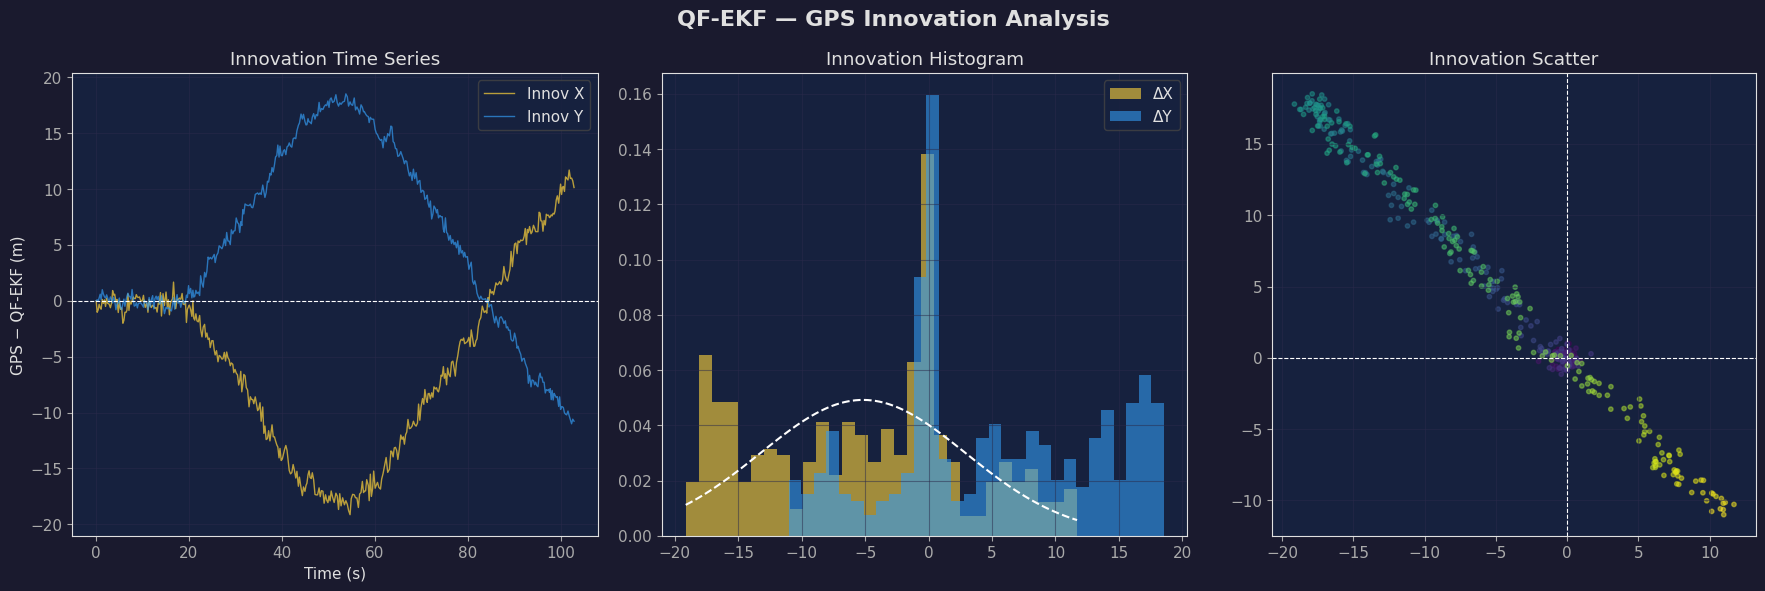


QF-EKF GPS Innovation:
  ΔX  mean=-5.1664  std=8.1106 m
  ΔY  mean=4.9776  std=8.0863 m
  2D RMSE = 13.5144 m
  Normality X: p=0.0000
  Normality Y: p=0.0000


In [9]:
if 'gps' not in dfs or 'ekf_global' not in dfs:
    print('Need /gps/fix and /odometry/global')
else:
    gps = dfs['gps']; ekf = dfs['ekf_global']
    lat = npc(gps,'lat'); lon = npc(gps,'lon')
    lat_m = (lat - lat[0]) * 111320
    lon_m = (lon - lon[0]) * 111320 * np.cos(np.radians(lat[0]))
    tg = npc(gps,'t'); te = npc(ekf,'t')
    xe = npc(ekf,'x'); ye = npc(ekf,'y')
    me = mask_finite(te, xe, ye)
    lat_m += xe[me][0] - lat_m[0]
    lon_m += ye[me][0] - lon_m[0]
    mg = mask_finite(tg, lat_m, lon_m)
    innov_x = lat_m[mg] - np.interp(tg[mg], te[me], xe[me])
    innov_y = lon_m[mg] - np.interp(tg[mg], te[me], ye[me])

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('QF-EKF — GPS Innovation Analysis', fontsize=16, fontweight='bold')

    axes[0].plot(tg[mg], innov_x, color=C['gps'], lw=1, label='Innov X', alpha=0.7)
    axes[0].plot(tg[mg], innov_y, color=C['ekf_global'], lw=1, label='Innov Y', alpha=0.7)
    axes[0].axhline(0, color='white', ls='--', lw=0.8)
    axes[0].set_title('Innovation Time Series')
    axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('GPS − QF-EKF (m)')
    axes[0].legend(); axes[0].grid(True)

    axes[1].hist(innov_x, bins=30, color=C['gps'], alpha=0.6, density=True, label='ΔX')
    axes[1].hist(innov_y, bins=30, color=C['ekf_global'], alpha=0.6, density=True, label='ΔY')
    xr = np.linspace(innov_x.min(), innov_x.max(), 100)
    axes[1].plot(xr, stats.norm.pdf(xr, innov_x.mean(), innov_x.std()), 'w--', lw=1.5)
    axes[1].set_title('Innovation Histogram'); axes[1].legend(); axes[1].grid(True)

    axes[2].scatter(innov_x, innov_y, c=tg[mg], cmap='viridis', s=10, alpha=0.5)
    axes[2].axhline(0, color='white', ls='--', lw=0.8)
    axes[2].axvline(0, color='white', ls='--', lw=0.8)
    axes[2].set_title('Innovation Scatter')
    axes[2].set_aspect('equal'); axes[2].grid(True)

    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/07_innovation.png', dpi=150, bbox_inches='tight')
    plt.show()

    rmse = np.sqrt(np.mean(innov_x**2 + innov_y**2))
    print('\nQF-EKF GPS Innovation:')
    print(f'  ΔX  mean={innov_x.mean():.4f}  std={innov_x.std():.4f} m')
    print(f'  ΔY  mean={innov_y.mean():.4f}  std={innov_y.std():.4f} m')
    print(f'  2D RMSE = {rmse:.4f} m')
    print(f'  Normality X: p={stats.normaltest(innov_x).pvalue:.4f}')
    print(f'  Normality Y: p={stats.normaltest(innov_y).pvalue:.4f}')